# Machine Learning Analysis of Groundwater Quality and Child Malnutrition Risk

## Project Overview
This project aims to analyze the relationship between environmental factors such as groundwater quality and sanitation with child malnutrition outcomes in rural India.

The study integrates:
- Groundwater quality data (pH, conductivity, temperature)
- NFHS health and sanitation data

Machine learning models are used to predict malnutrition risk based on environmental indicators.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

## Data Loading

In this step, we load:
- NFHS dataset (health, sanitation, malnutrition)
- Groundwater dataset (environmental variables)

These datasets will be used for analysis and model building.

In [4]:
nfhs = pd.read_csv('nfhs.csv')
water = pd.read_csv('groundwater.csv')

print("NFHS Data:")
display(nfhs.head())

print("Groundwater Data:")
display(water.head())

NFHS Data:


,District Names,State/UT,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)","Sex ratio at birth for children born in the last five years (females per 1,000 males)",Children under age 5 years whose birth was registered with the civil authority (%),...,Men age 15 years and above wih Mildly elevated blood pressure (Systolic 140-159 mm of Hg and/or Diastolic 90-99 mm of Hg) (%),Men age 15 years and above wih Moderately or severely elevated blood pressure (Systolic ?160 mm of Hg and/or Diastolic ?100 mm of Hg) (%),Men age 15 years and above wih Elevated blood pressure (Systolic ?140 mm of Hg and/or Diastolic ?90 mm of Hg) or taking medicine to control blood pressure (%),Women (age 30-49 years) Ever undergone a screening test for cervical cancer (%),Women (age 30-49 years) Ever undergone a breast examination for breast cancer (%),Women (age 30-49 years) Ever undergone an oral cavity examination for oral cancer (%),Women age 15 years and above who use any kind of tobacco (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who consume alcohol (%)
0,Nicobars,Andaman & Nicobar Islands,882,764,125,78.0,23.0,973,927,98.0,...,32.9,11.1,47.0,13.4,13.2,5.4,63.5,76.8,29.6,64.5
1,North & Middle Andaman,Andaman & Nicobar Islands,874,789,108,82.7,19.8,950,844,100.0,...,22.6,6.0,32.2,1.7,0.3,15.8,46.8,70.5,5.1,45.3
2,South Andaman,Andaman & Nicobar Islands,868,844,134,84.7,21.0,967,935,96.5,...,17.9,6.1,26.9,1.3,0.7,8.0,19.6,50.8,1.7,32.8
3,Srikakulam,Andhra Pradesh,874,780,100,60.0,20.7,1140,1163,95.0,...,14.4,5.5,22.9,1.0,0.2,3.8,7.1,21.3,0.6,28.3
4,Vizianagaram,Andhra Pradesh,902,853,134,56.0,20.6,1114,898,95.4,...,14.8,6.4,25.1,4.9,0.6,7.3,11.4,21.5,0.8,32.3


Groundwater Data:


,Station Code,Station Name,STATE,Temperature Min,Temperature Max,pH Min,pH Max,Conductivity (µmhos/cm) Min,Conductivity (µmhos/cm) Max,Year
0,15,"WELL AT KUYYURA, A.P.",ANDHRA PRADESH,23.0,28.0,6.82,7.85,195.0,226.0,2012
1,16,WELL AT TADAVAI A.P.,ANDHRA PRADESH,27.0,28.0,7.21,7.72,663.0,1121.0,2012
2,26,"WELL AT VIJAYWADA, A.P.",ANDHRA PRADESH,26.0,32.0,7.19,7.39,1601.0,1661.0,2012
3,27,"WELL AT PEDDAVOORA, A.P.",ANDHRA PRADESH,26.0,27.0,7.82,8.80,1420.0,1668.0,2012
4,1513,"B W. - KRISHNA MURTHY, D.NO. 48-16-43 AUTONAGA...",ANDHRA PRADESH,25.0,30.0,6.80,7.11,1454.0,1575.0,2012


## Data Exploration

We examine the structure and column names of both datasets to identify relevant variables.

In [5]:
print("NFHS Columns:")
print(nfhs.columns)

print("\nGroundwater Columns:")
print(water.columns)

NFHS Columns:
Index(['District Names', 'State/UT', 'Number of Households surveyed',
       'Number of Women age 15-49 years interviewed',
       'Number of Men age 15-54 years interviewed',
       'Female population age 6 years and above who ever attended school (%)',
       'Population below age 15 years (%)',
       ' Sex ratio of the total population (females per 1,000 males)',
       'Sex ratio at birth for children born in the last five years (females per 1,000 males)',
       'Children under age 5 years whose birth was registered with the civil authority (%)',
       ...
       'Men age 15 years and above wih Mildly elevated blood pressure (Systolic 140-159 mm of Hg and/or Diastolic 90-99 mm of Hg) (%)',
       'Men age 15 years and above wih Moderately or severely elevated blood pressure (Systolic ?160 mm of Hg and/or Diastolic ?100 mm of Hg) (%)',
       'Men age 15 years and above wih Elevated blood pressure (Systolic ?140 mm of Hg and/or Diastolic ?90 mm of Hg) or taking medi

## Data Cleaning

We standardize column names and rename key columns for easier processing and merging.

In [6]:
# Standardize column names
nfhs.columns = nfhs.columns.str.lower().str.strip()
water.columns = water.columns.str.lower().str.strip()

# Rename important columns
nfhs = nfhs.rename(columns={
    'district names': 'district',
    'state/ut': 'state'
})

water = water.rename(columns={
    'state': 'state'
})

print(nfhs.columns)
print(water.columns)

Index(['district', 'state', 'number of households surveyed',
       'number of women age 15-49 years interviewed',
       'number of men age 15-54 years interviewed',
       'female population age 6 years and above who ever attended school (%)',
       'population below age 15 years (%)',
       'sex ratio of the total population (females per 1,000 males)',
       'sex ratio at birth for children born in the last five years (females per 1,000 males)',
       'children under age 5 years whose birth was registered with the civil authority (%)',
       ...
       'men age 15 years and above wih mildly elevated blood pressure (systolic 140-159 mm of hg and/or diastolic 90-99 mm of hg) (%)',
       'men age 15 years and above wih moderately or severely elevated blood pressure (systolic ?160 mm of hg and/or diastolic ?100 mm of hg) (%)',
       'men age 15 years and above wih elevated blood pressure (systolic ?140 mm of hg and/or diastolic ?90 mm of hg) or taking medicine to control blood pr

## Cleaning Text Values

We standardize text formatting for merging datasets.

In [7]:
nfhs['state'] = nfhs['state'].str.upper().str.strip()
water['state'] = water['state'].str.upper().str.strip()

## Filtering Data for Uttar Pradesh

We focus only on Uttar Pradesh as per the research objective.

In [8]:
nfhs_up = nfhs[nfhs['state'] == 'UTTAR PRADESH']
water_up = water[water['state'] == 'UTTAR PRADESH']

print("NFHS UP shape:", nfhs_up.shape)
print("Water UP shape:", water_up.shape)

NFHS UP shape: (75, 109)
Water UP shape: (33, 10)


## Computing Average Water Quality Indicators

We compute average values from min and max measurements.

In [9]:
water_up['temperature'] = (water_up['temperature min'] + water_up['temperature max']) / 2
water_up['ph'] = (water_up['ph min'] + water_up['ph max']) / 2
water_up['conductivity'] = (
    water_up['conductivity (µmhos/cm) min'] +
    water_up['conductivity (µmhos/cm) max']
) / 2

/tmp/ipykernel_2902/813402664.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  water_up['temperature'] = (water_up['temperature min'] + water_up['temperature max']) / 2
/tmp/ipykernel_2902/813402664.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  water_up['ph'] = (water_up['ph min'] + water_up['ph max']) / 2
/tmp/ipykernel_2902/813402664.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the ca

## Aggregating Water Data

We compute average groundwater parameters for Uttar Pradesh.

In [10]:
water_avg = water_up[['state','temperature','ph','conductivity']].groupby('state').mean().reset_index()

display(water_avg)

,state,temperature,ph,conductivity
0,UTTAR PRADESH,24.82037,7.307576,918.157576


## Merging Datasets

We merge NFHS and groundwater datasets using the state column.

In [11]:
merged = pd.merge(nfhs_up, water_avg, on='state')

print("Merged shape:", merged.shape)
display(merged.head())

Merged shape: (75, 112)


,district,state,number of households surveyed,number of women age 15-49 years interviewed,number of men age 15-54 years interviewed,female population age 6 years and above who ever attended school (%),population below age 15 years (%),"sex ratio of the total population (females per 1,000 males)","sex ratio at birth for children born in the last five years (females per 1,000 males)",children under age 5 years whose birth was registered with the civil authority (%),...,women (age 30-49 years) ever undergone a screening test for cervical cancer (%),women (age 30-49 years) ever undergone a breast examination for breast cancer (%),women (age 30-49 years) ever undergone an oral cavity examination for oral cancer (%),women age 15 years and above who use any kind of tobacco (%),men age 15 years and above who use any kind of tobacco (%),women age 15 years and above who consume alcohol (%),men age 15 years and above who consume alcohol (%),temperature,ph,conductivity
0,Saharanpur,UTTAR PRADESH,966,1318,183,69.3,28.5,984,1022,85.4,...,0.2,0.1,0.2,2.4,30.7,0.5,14.1,24.82037,7.307576,918.157576
1,Bijnor,UTTAR PRADESH,949,1348,178,69.6,30.7,1059,951,85.7,...,0.0,0.0,0.2,3.6,36.5,0.2,15.1,24.82037,7.307576,918.157576
2,Rampur,UTTAR PRADESH,876,1092,145,57.6,31.1,1022,968,71.5,...,0.4,0.2,0.4,4.9,36.1,0.1,14.6,24.82037,7.307576,918.157576
3,Jyotiba Phule Nagar,UTTAR PRADESH,973,1411,165,63.7,32.5,1001,860,78.1,...,0.0,0.2,0.2,4.4,38.9,0.4,14.4,24.82037,7.307576,918.157576
4,Meerut,UTTAR PRADESH,918,1212,169,74.0,30.3,967,926,80.2,...,0.2,0.0,0.0,2.6,24.4,0.2,13.7,24.82037,7.307576,918.157576


## Identifying Malnutrition Indicators

We extract relevant columns related to child malnutrition:
- Stunting
- Wasting
- Underweight

In [12]:
for col in merged.columns:
    if "stunt" in col.lower():
        print(col)

children under 5 years who are stunted (height-for-age)18 (%)


In [13]:
for col in merged.columns:
    if "wast" in col.lower():
        print(col)

children under 5 years who are wasted (weight-for-height)18 (%)
children under 5 years who are severely wasted (weight-for-height)19 (%)


In [14]:
for col in merged.columns:
    if "underweight" in col.lower():
        print(col)

children under 5 years who are underweight (weight-for-age)18 (%)


## Renaming Target Variables

We rename malnutrition-related columns for simplicity and consistency in modeling.

In [15]:
merged = merged.rename(columns={
    'children under 5 years who are stunted (height-for-age)18 (%)': 'stunting',
    'children under 5 years who are wasted (weight-for-height)18 (%)': 'wasting',
    'children under 5 years who are underweight (weight-for-age)18 (%)': 'underweight'
})

## Converting Columns to Numeric

Malnutrition indicators are currently stored as strings.
We convert them into numeric values for computation.

In [16]:
# Convert columns to numeric
merged['stunting'] = pd.to_numeric(merged['stunting'], errors='coerce')
merged['wasting'] = pd.to_numeric(merged['wasting'], errors='coerce')
merged['underweight'] = pd.to_numeric(merged['underweight'], errors='coerce')

In [17]:
merged[['stunting','wasting','underweight']].describe()

,stunting,wasting,underweight
count,75.000000,75.000000,75.000000
mean,39.634667,17.692000,32.317333
std,6.985226,4.959096,6.001652
min,25.400000,9.100000,21.300000
25%,34.850000,13.850000,27.550000
50%,39.700000,18.100000,32.600000
75%,44.800000,21.450000,36.450000
max,52.100000,26.800000,49.800000


## Creating Target Variable

A composite malnutrition score is calculated as the average of:
- Stunting
- Wasting
- Underweight

In [18]:
merged['malnutrition_score'] = (
    merged['stunting'] +
    merged['wasting'] +
    merged['underweight']
) / 3

merged[['stunting','wasting','underweight','malnutrition_score']].head()

,stunting,wasting,underweight,malnutrition_score
0,28.8,22.0,26.7,25.833333
1,36.2,9.4,21.9,22.500000
2,40.4,17.6,32.1,30.033333
3,42.2,22.5,35.4,33.366667
4,32.1,10.2,23.7,22.000000


## Identifying Sanitation Variable

We extract sanitation-related indicators from the dataset to use as an important environmental predictor.

In [19]:
for col in merged.columns:
    if "sanitation" in col.lower():
        print(col)

population living in households that use an improved sanitation facility2 (%)


## Renaming Sanitation Variable

We rename the sanitation column for simplicity and clarity in modeling.

In [20]:
merged = merged.rename(columns={
    'population living in households that use an improved sanitation facility2 (%)': 'sanitation'
})

In [21]:
print(merged[['sanitation']].head())

   sanitation
0        83.8
1        78.2
2        79.0
3        78.9
4        82.7


## Feature Selection

We select relevant environmental variables as input features:
- Groundwater quality indicators (pH, conductivity, temperature)
- Sanitation

Target variable:
- Malnutrition score

In [22]:
X = merged[['ph', 'conductivity', 'temperature', 'sanitation']]
y = merged['malnutrition_score']

## Train-Test Split

The dataset is split into training and testing sets (80-20 split).

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Training

We use Random Forest Regressor to model nonlinear relationships between environmental factors and malnutrition.

In [24]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

## Model Prediction

We generate predictions on the test dataset.

In [25]:
predictions = model.predict(X_test)

## Model Evaluation

Model performance is evaluated using:
- R² Score
- Root Mean Square Error (RMSE)

In [26]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, predictions))

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print("RMSE:", rmse)

R2 Score: -0.24065331892622877
RMSE: 5.595381481858643


## Key Insight from Initial Model

- The model produced a negative R² score, indicating poor predictive performance.

- Groundwater variables (pH, conductivity, temperature) are constant across districts, as data is available only at the state level.

- Due to lack of variability, these features do not contribute effectively to prediction.

- Machine learning models require feature variation to learn meaningful patterns.

- Sanitation, which varies at the district level, is likely a stronger predictor of malnutrition.

Next step: Evaluate a simplified model using sanitation as the primary feature.

## Baseline Model: Sanitation as Predictor

Since groundwater variables lack district-level variation, we evaluate a simplified model using sanitation as the primary predictor.

This helps assess the true predictive strength of sanitation on malnutrition.

In [27]:
# Define features
X_simple = merged[['sanitation']]
y = merged['malnutrition_score']

# Train-test split
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Train model
model_simple = RandomForestRegressor(random_state=42)
model_simple.fit(X_train, y_train)

# Predict
pred_simple = model_simple.predict(X_test)

# Evaluate
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, pred_simple))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_simple)))

R2 Score: -0.24065331892622877
RMSE: 5.595381481858643


## Limitation and Model Improvement Strategy

- The baseline model using sanitation showed limited predictive performance.

- This indicates that malnutrition cannot be explained by a single variable.

- Additionally, groundwater variables lacked district-level variation, reducing their usefulness in prediction.

- Malnutrition is influenced by multiple factors such as education, living conditions, and access to resources.

To address this, we expand the feature set by incorporating additional socioeconomic and household indicators from the NFHS dataset.

In [28]:
for col in merged.columns:
    if any(word in col.lower() for word in ["school", "education", "electricity", "water", "fuel"]):
        print(col)

female population age 6 years and above who ever attended school (%)
population living in households with electricity (%)
population living in households with an improved drinking-water source1 (%)
households using clean fuel for cooking3 (%)
children age 5 years who attended pre-primary school during the school year 2019-20 (%)
women (age 15-49)  with 10 or more years of schooling (%)


## Improved Feature Selection

We expand the model by including key socioeconomic and household indicators:

- Sanitation
- Electricity access
- Drinking water access
- Clean cooking fuel
- Women's education

These variables better represent living conditions and are expected to improve prediction.

In [29]:
# Rename columns for simplicity

merged = merged.rename(columns={
    'population living in households with electricity (%)': 'electricity',
    'population living in households with an improved drinking-water source1 (%)': 'drinking_water',
    'households using clean fuel for cooking3 (%)': 'clean_fuel',
    'women (age 15-49)  with 10 or more years of schooling (%)': 'women_education'
})

In [30]:
X = merged[['sanitation', 'electricity', 'drinking_water', 'clean_fuel', 'women_education']]
y = merged['malnutrition_score']

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_final = RandomForestRegressor(random_state=42)
model_final.fit(X_train, y_train)

pred_final = model_final.predict(X_test)

In [32]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, pred_final))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_final)))

R2 Score: 0.4570125089185181
RMSE: 3.7016844343962982


## Feature Importance (Improved Model)

We evaluate which factors contribute most to malnutrition prediction.

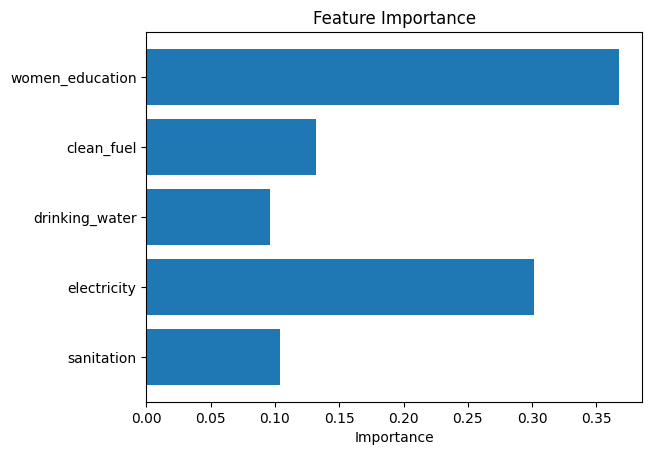

In [33]:
import matplotlib.pyplot as plt

importance = model_final.feature_importances_

plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

## Final Conclusion

- The improved model achieved significantly better performance (R² = 0.457), indicating that socioeconomic and household factors play a major role in predicting child malnutrition.

- Women’s education emerged as the most important predictor, followed by electricity access, highlighting the role of awareness and living conditions.

- Environmental factors such as sanitation and drinking water, while relevant, were not sufficient alone to explain malnutrition patterns.

- This demonstrates that child malnutrition is a multi-dimensional problem influenced by education, infrastructure, and household conditions.

Conclusion: Effective interventions must go beyond water quality and focus on improving education, living standards, and access to resources.

# Data Profile & WHO Assessment Basis

This study utilizes district-level data from the National Family Health Survey (NFHS-5) conducted between 2019 and 2021. The analysis is focused on rural districts of Uttar Pradesh, covering approximately 75 districts.

The demographic scope includes:
- Children under the age of 5 years (for malnutrition indicators)
- Women aged 15–49 years (for socioeconomic indicators)

Child malnutrition is assessed based on the WHO Child Growth Standards (2006), which define nutritional status using Z-scores:

- Stunting (Height-for-Age): Z-score < -2 SD  
- Wasting (Weight-for-Height): Z-score < -2 SD  
- Underweight (Weight-for-Age): Z-score < -2 SD  

The composite malnutrition score used in this study is derived by averaging these three indicators, providing a unified measure of nutritional status across districts.

# Advanced Modeling with LightGBM

To further enhance model performance and validate the robustness of results, Light Gradient Boosting Machine (LightGBM) is introduced as an additional model.

LightGBM is an efficient gradient boosting framework that is particularly effective for handling structured data and capturing complex non-linear relationships.

The model is trained using the same feature set and evaluation strategy as previous models to ensure consistency in comparison.

In [34]:
# Install LightGBM (if not already installed)
!pip install lightgbm

from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Initialize model
lgbm_model = LGBMRegressor(random_state=42)

# Train model
lgbm_model.fit(X_train, y_train)

# Predict
lgbm_pred = lgbm_model.predict(X_test)

# Evaluate
lgbm_r2 = r2_score(y_test, lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_pred))

print("LightGBM R2 Score:", lgbm_r2)
print("LightGBM RMSE:", lgbm_rmse)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000256 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 96
[LightGBM] [Info] Number of data points in the train set: 60, number of used features: 5
[LightGBM] [Info] Start training from score 29.832778
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

# Prevalence and Geospatial Hotspot Analysis

This section identifies districts with the highest burden of child malnutrition, referred to as "hotspots".

Hotspots are determined based on the composite malnutrition score, allowing for comparison across districts.

The top 15 districts with the highest malnutrition scores are visualized to highlight regions requiring targeted intervention.

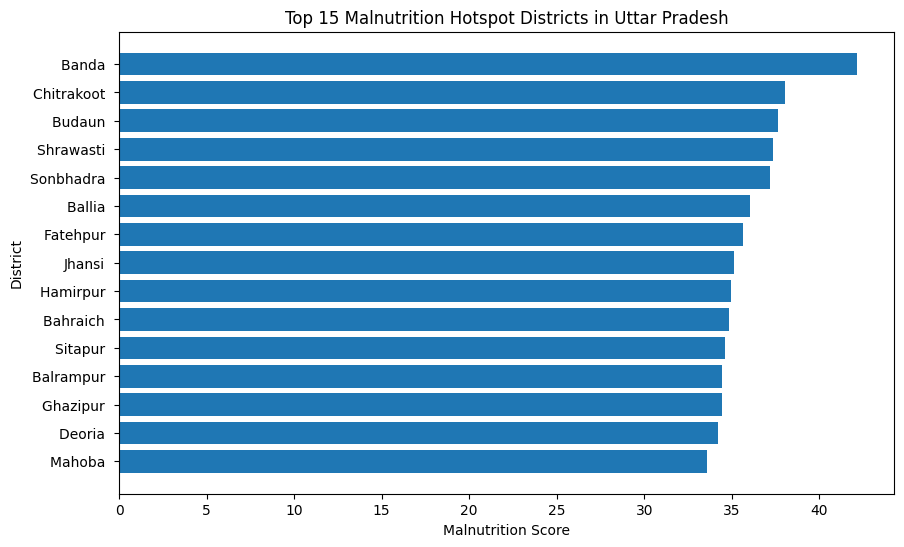

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a copy to avoid modifying original data
geo_df = merged.copy()

# Sort districts by malnutrition score (descending)
hotspots = geo_df.sort_values(by='malnutrition_score', ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(hotspots['district'], hotspots['malnutrition_score'])
plt.xlabel("Malnutrition Score")
plt.ylabel("District")
plt.title("Top 15 Malnutrition Hotspot Districts in Uttar Pradesh")
plt.gca().invert_yaxis()
plt.show()

# Model Comparison

To evaluate model performance comprehensively, multiple models are compared using the same dataset and evaluation metrics.

The comparison includes:
- Random Forest (baseline)
- XGBoost (if already used)
- LightGBM (newly added)

This helps validate the effectiveness of the chosen model and ensures robustness of results.

In [36]:
import pandas as pd

# Store results (make sure rf_r2 etc. exist from your previous code)
results = pd.DataFrame({
    'Model': ['Random Forest', 'LightGBM'],
    'R2 Score': [r2_score(y_test, predictions), lgbm_r2],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, predictions)),
        lgbm_rmse
    ]
})

results

,Model,R2 Score,RMSE
0,Random Forest,-0.240653,5.595381
1,LightGBM,0.507396,3.525767


# Retrained Model with Complete Feature Set

To ensure consistency between data analysis and model training, the model is retrained using the full set of socioeconomic features:

- sanitation  
- electricity  
- drinking water  
- clean fuel  
- women education  

This allows the model to capture the combined influence of all relevant variables and produce more reliable feature importance results.

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Define FULL feature set
X_full = merged[['sanitation', 'electricity', 'drinking_water', 'clean_fuel', 'women_education']]
y_full = merged['malnutrition_score']

# Train-test split
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

# 🔥 OPTIMIZED RANDOM FOREST
model_full = RandomForestRegressor(
    n_estimators=300,        # more trees
    max_depth=10,            # controlled depth
    min_samples_split=5,     # avoids overfitting
    min_samples_leaf=2,      # smoother predictions
    random_state=42
)

# Train
model_full.fit(X_train_full, y_train_full)

# Predict
pred_full = model_full.predict(X_test_full)

# Evaluate
r2_full = r2_score(y_test_full, pred_full)
rmse_full = np.sqrt(mean_squared_error(y_test_full, pred_full))

print("Optimized Model R2 Score:", r2_full)
print("Optimized Model RMSE:", rmse_full)

Optimized Model R2 Score: 0.48944025807253233
Optimized Model RMSE: 3.5894488090565675


# Feature Importance (Retrained Model)

Feature importance is recalculated using the retrained model to reflect the contribution of all variables.

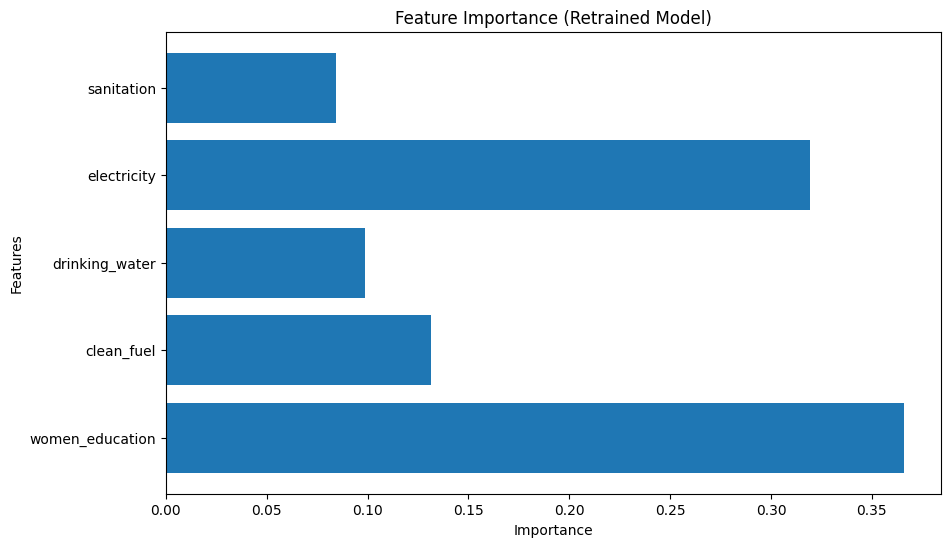

In [38]:
import matplotlib.pyplot as plt

importances_full = model_full.feature_importances_
features_full = X_train_full.columns

plt.figure(figsize=(10,6))
plt.barh(features_full, importances_full)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance (Retrained Model)")
plt.gca().invert_yaxis()
plt.show()

# Model Evaluation Visualization

To further validate model performance, prediction accuracy is analyzed using:

- Predicted vs Actual comparison
- Residual analysis

These visualizations help assess model reliability and error distribution.

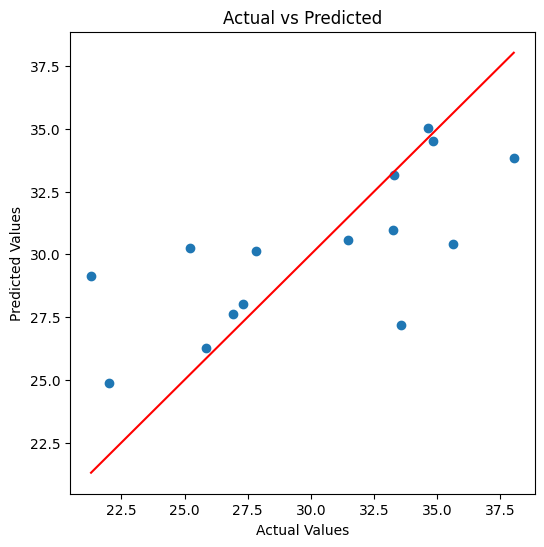

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test_full, pred_full)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.plot([y_test_full.min(), y_test_full.max()],
         [y_test_full.min(), y_test_full.max()],
         color='red')
plt.show()

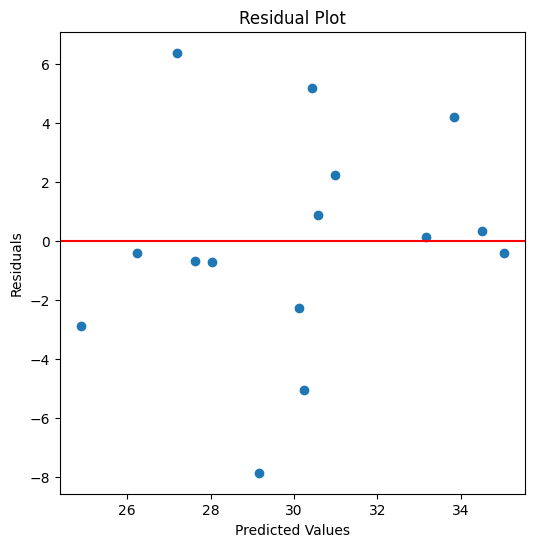

In [40]:
residuals = y_test_full - pred_full

plt.figure(figsize=(6,6))
plt.scatter(pred_full, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()